In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from timesfm3.mlx import TimesFM3Forecaster, ModelConfig

In [2]:
df = pd.read_parquet(
    "../data/processed/sardinia_hourly.parquet"
).copy()

df = df.rename(
    columns={"Total Load [MW]": "load"}
)

df = df[["load"]]

print(df.shape)
print(df.index.min(), "->", df.index.max())
print(f"Missing: {df['load'].isna().sum()}")

df.head()

(32975, 1)
2023-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00
Missing: 48


,load
Date,
2023-01-01 00:00:00+01:00,806.13675
2023-01-01 01:00:00+01:00,783.55525
2023-01-01 02:00:00+01:00,753.62675
2023-01-01 03:00:00+01:00,736.34950
2023-01-01 04:00:00+01:00,723.29950


In [3]:
config = ModelConfig(
    checkpoint_path="google/timesfm-3.0-pytorch",
    per_core_batch_size=16,
    compile=False,
)

model = TimesFM3Forecaster(config)

/Users/aserra/miniforge3/envs/timeseries/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
context_length = 14 * 24
horizon = 24

test_days = pd.date_range(
    start="2026-01-01",
    end="2026-10-05",
    freq="D",
    tz="Europe/Rome",
)

forecasts = []

for forecast_start in test_days:

    history = df.loc[
        df.index < forecast_start,
        "load",
    ].tail(context_length)

    actual = df.loc[
        (df.index >= forecast_start)
        & (df.index < forecast_start + pd.Timedelta(hours=24)),
        "load",
    ]

    # Require a complete 336 h context and 24 h target
    if (
        len(history) != context_length
        or history.isna().any()
        or len(actual) != horizon
        or actual.isna().any()
    ):
        continue

    prediction = model.predict(
        history.to_numpy(dtype=np.float32),
        horizon=horizon,
        return_quantiles=False,
    ).forecast

    day_result = pd.DataFrame(
        {
            "actual": actual.to_numpy(),
            "prediction": prediction,
        },
        index=actual.index,
    )

    forecasts.append(day_result)

results_timesfm = pd.concat(forecasts)

print(f"Forecasted hours: {len(results_timesfm):,}")
print(f"Forecasted days:  {len(forecasts):,}")
print(
    results_timesfm.index.min(),
    "->",
    results_timesfm.index.max(),
)

Forecasted hours: 6,288
Forecasted days:  262
2026-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00


In [5]:
context = history.to_numpy(dtype=np.float32)

output = model.predict(
    context,
    horizon=horizon,
    return_quantiles=True,
)

prediction = output.forecast

print(prediction.shape)
print(prediction)

(24,)
[ 721.9991   698.40955  691.5516   692.24854  700.8787   733.10913
  815.594    903.92285  963.52716  999.34174 1002.8283  1012.3746
 1015.7638  1004.43335  976.504    951.27716  935.49695  947.1763
  976.2665  1034.5989  1028.8341   946.02295  870.1618   802.1677 ]


In [6]:
actual = df.loc[
    (df.index >= forecast_start)
    & (df.index < forecast_start + pd.Timedelta(hours=24)),
    "load",
]

comparison = pd.DataFrame(
    {
        "actual": actual.to_numpy(),
        "prediction": prediction,
    },
    index=actual.index,
)

comparison.head()

,actual,prediction
Date,,
2026-10-05 00:00:00+02:00,722.9945,721.999084
2026-10-05 01:00:00+02:00,697.5705,698.409546
2026-10-05 02:00:00+02:00,690.7690,691.551575
2026-10-05 03:00:00+02:00,687.1645,692.248535
2026-10-05 04:00:00+02:00,698.7755,700.878723


In [7]:
mae = mean_absolute_error(
    comparison["actual"],
    comparison["prediction"],
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["actual"],
        comparison["prediction"],
    )
)

mape = mean_absolute_percentage_error(
    comparison["actual"],
    comparison["prediction"],
) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  16.60 MW
RMSE: 26.04 MW
MAPE: 1.67%


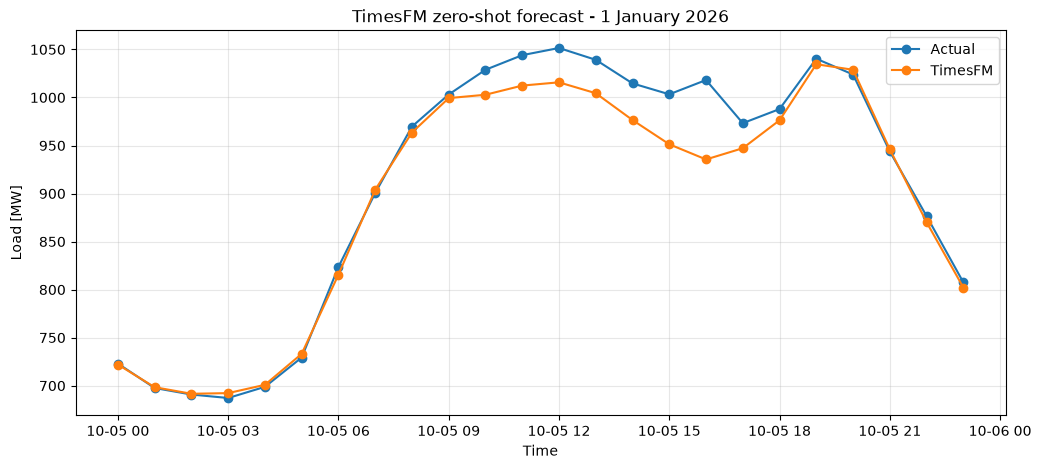

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    comparison.index,
    comparison["actual"],
    marker="o",
    label="Actual",
)

ax.plot(
    comparison.index,
    comparison["prediction"],
    marker="o",
    label="TimesFM",
)

ax.set_title("TimesFM zero-shot forecast - 1 January 2026")
ax.set_xlabel("Time")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [9]:
mae = mean_absolute_error(
    results_timesfm["actual"],
    results_timesfm["prediction"],
)

rmse = np.sqrt(
    mean_squared_error(
        results_timesfm["actual"],
        results_timesfm["prediction"],
    )
)

mape = mean_absolute_percentage_error(
    results_timesfm["actual"],
    results_timesfm["prediction"],
) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  29.40 MW
RMSE: 42.79 MW
MAPE: 2.82%


In [10]:
xgb_results = pd.read_parquet(
    "../data/processed/xgb_predictions.parquet"
)
terna = pd.read_parquet(
    "../data/processed/sardinia_hourly.parquet"
)[["Forecast Total Load [MW]"]].copy()

terna.index = terna.index.tz_convert("UTC")

In [11]:
results_timesfm_utc = results_timesfm.copy()
results_timesfm_utc.index = results_timesfm_utc.index.tz_convert("UTC")

comparison = pd.DataFrame({
    "actual": xgb_results["actual"],
    "xgboost": xgb_results["prediction"],
}).join(
    results_timesfm_utc[["prediction"]].rename(
        columns={"prediction": "timesfm"}
    ),
    how="inner",
)

print(comparison.shape)
print(comparison.index.min(), "->", comparison.index.max())
print(comparison.isna().sum())

(6288, 3)
2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00
actual     0
xgboost    0
timesfm    0
dtype: int64


In [12]:
for model_name in ["xgboost", "timesfm"]:

    mae = mean_absolute_error(
        comparison["actual"],
        comparison[model_name],
    )

    rmse = np.sqrt(
        mean_squared_error(
            comparison["actual"],
            comparison[model_name],
        )
    )

    mape = mean_absolute_percentage_error(
        comparison["actual"],
        comparison[model_name],
    ) * 100

    print(
        f"{model_name:8s} | "
        f"MAE: {mae:6.2f} MW | "
        f"RMSE: {rmse:6.2f} MW | "
        f"MAPE: {mape:5.2f}%"
    )

xgboost  | MAE:  32.04 MW | RMSE:  47.10 MW | MAPE:  2.96%
timesfm  | MAE:  29.40 MW | RMSE:  42.79 MW | MAPE:  2.82%


In [13]:
comparison = comparison.join(
    terna.rename(
        columns={"Forecast Total Load [MW]": "terna"}
    ),
    how="inner",
)


print(comparison.shape)
print(comparison.isna().sum())

(6288, 4)
actual     0
xgboost    0
timesfm    0
terna      0
dtype: int64


In [14]:
metrics = []

for model_name in ["xgboost", "timesfm", "terna"]:

    mae = mean_absolute_error(
        comparison["actual"],
        comparison[model_name],
    )

    rmse = np.sqrt(
        mean_squared_error(
            comparison["actual"],
            comparison[model_name],
        )
    )

    mape = mean_absolute_percentage_error(
        comparison["actual"],
        comparison[model_name],
    ) * 100

    metrics.append({
        "model": model_name,
        "MAE [MW]": mae,
        "RMSE [MW]": rmse,
        "MAPE [%]": mape,
    })

metrics_df = pd.DataFrame(metrics).set_index("model")

metrics_df.round(2)

,MAE [MW],RMSE [MW],MAPE [%]
model,,,
xgboost,32.04,47.10,2.96
timesfm,29.40,42.79,2.82
terna,16.37,23.08,1.57


## Future calendar and weather covariates

The original univariate analysis above is preserved. This section is self-contained and can be run independently, in order, starting here.

Compare three fixed configurations on **October–December 2025**: load only, calendar, and calendar plus weather. Select by lowest **validation MAE**, with the listed order breaking exact ties. Also identify the best covariate variant for the requested final comparison; if the baseline wins overall, report that rather than claiming a covariate improvement. Only the selected covariate variant and the required univariate reference are then forecast on 2026. No settings are changed after test results are seen.

Keep 336 context hours, a 24-hour horizon, the existing checkpoint, and MLX inference settings. Calendar channels are the requested numeric hour, weekday, weekend, and Italian-holiday indicators; no feature search, external regression fit, or fine-tuning is performed.

In [15]:
from pathlib import Path
from importlib.metadata import version
import inspect
import holidays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from timesfm3.mlx import TimesFM3Forecaster, ModelConfig

context_length_cov = 336
horizon_cov = 24
checkpoint_revision = "43046b85ec22d584a13f8098c2ed39c889e129c2"

print("TimesFM:", version("timesfm"))
print("MLX:", version("mlx"))
print("Checkpoint revision:", checkpoint_revision)
assert "past_future_covariates" in inspect.signature(TimesFM3Forecaster.predict).parameters

TimesFM: 3.0.2
MLX: 0.32.3
Checkpoint revision: 43046b85ec22d584a13f8098c2ed39c889e129c2


### API and forecast-time information

The installed [TimesFM 3 MLX implementation](https://github.com/google-research/timesfm/blob/master/src/timesfm3/mlx/timesfm3_forecaster.py) accepts a one-dimensional load context and `past_future_covariates` shaped **(number of channels, 336 + 24)**. Each channel contains aligned historical and future values. The returned point forecast contains only the 24 target load predictions. The checkpoint revision is pinned for reproducibility; its repository name includes “pytorch”, but execution uses MLX.

Load input ends one hour before the forecast starts. Future load is used only for scoring and completeness checks. Terna is loaded only after selection as an external benchmark. Weather inputs use the supplied historical previous-day forecasts throughout, never realized weather. Their availability at the midnight issue time is assumed from the dataset description; the processed parquet has no issuance timestamps with which to independently audit that assumption. This experiment also assumes the last completed load hour is available without publication delay.

In [16]:
load_cov = pd.read_parquet(
    "../data/processed/sardinia_hourly.parquet"
)[["Total Load [MW]"]].rename(columns={"Total Load [MW]": "load"})
load_cov.index = load_cov.index.tz_convert("UTC")
load_cov = load_cov.sort_index()

weather_cov = pd.read_parquet(
    "../data/processed/sardinia_weather_hourly.parquet"
).copy()
weather_cov.index = weather_cov.index.tz_convert("UTC")

assert load_cov.index.is_unique and weather_cov.index.is_unique
calendar_features_cov = ["hour", "day_of_week", "is_weekend", "is_holiday"]
weather_features_cov = [
    "temperature_weighted", "humidity_weighted", "cloud_cover_weighted",
    "temperature_min", "temperature_max",
]

covariate_df = load_cov.join(weather_cov[weather_features_cov], how="left")
local_index_cov = covariate_df.index.tz_convert("Europe/Rome")
italian_holidays_cov = holidays.Italy(
    years=range(local_index_cov.year.min(), local_index_cov.year.max() + 1)
)
covariate_df["hour"] = local_index_cov.hour
covariate_df["day_of_week"] = local_index_cov.dayofweek
covariate_df["is_weekend"] = (local_index_cov.dayofweek >= 5).astype(int)
covariate_df["is_holiday"] = [
    int(date in italian_holidays_cov) for date in local_index_cov.date
]

covariate_sets = {
    "univariate": [],
    "calendar": calendar_features_cov,
    "calendar_weather": calendar_features_cov + weather_features_cov,
}
assert "Forecast Total Load [MW]" not in covariate_df.columns
covariate_df.head()

,load,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max,hour,day_of_week,is_weekend,is_holiday
Date,,,,,,,,,,
2022-12-31 23:00:00+00:00,806.13675,NaN,NaN,NaN,NaN,NaN,0,6,1,1
2023-01-01 00:00:00+00:00,783.55525,NaN,NaN,NaN,NaN,NaN,1,6,1,1
2023-01-01 01:00:00+00:00,753.62675,NaN,NaN,NaN,NaN,NaN,2,6,1,1
2023-01-01 02:00:00+00:00,736.34950,NaN,NaN,NaN,NaN,NaN,3,6,1,1
2023-01-01 03:00:00+00:00,723.29950,NaN,NaN,NaN,NaN,NaN,4,6,1,1


### Exact hourly windows and daylight saving time

Forecasts start at Europe/Rome midnight. Explicit UTC hourly indexes require **every** context and target hour to exist: missing timestamps become NaN and cause the whole forecast to be skipped. No interpolation or compression across the January 2026 gap is used.

Skip local days with 23 or 25 hours to preserve both the fixed 24-hour horizon and unique, non-overlapping evaluation timestamps. The earlier fixed-24-hour loop overlaps the following midnight on the spring transition; therefore its 6,288-row reference is not the expected row count for this stricter comparison. The original results remain above, and every new table reports its own common count.

All three validation variants use the same eligibility rules, including complete weather for the context and horizon. The selection period contains no summer: summer results are descriptive tests of transfer, not grounds for further tuning.

In [17]:
validation_start_cov = pd.Timestamp("2025-10-01", tz="Europe/Rome")
test_start_cov = pd.Timestamp("2026-01-01", tz="Europe/Rome")
validation_days_cov = pd.date_range(
    validation_start_cov, test_start_cov, freq="D", inclusive="left"
)

# One small shared loop keeps validation and test window construction identical.
def forecast_covariate_days(forecast_days, feature_sets):
    forecasts_cov = []
    skipped_cov = []
    all_features_cov = calendar_features_cov + weather_features_cov

    for day_number, forecast_start_cov in enumerate(forecast_days, start=1):
        next_midnight_cov = forecast_start_cov + pd.DateOffset(days=1)
        if next_midnight_cov - forecast_start_cov != pd.Timedelta(hours=horizon_cov):
            skipped_cov.append({"day": forecast_start_cov, "reason": "DST day is not 24 hours"})
            continue

        start_utc_cov = forecast_start_cov.tz_convert("UTC")
        context_index_cov = pd.date_range(
            end=start_utc_cov - pd.Timedelta(hours=1),
            periods=context_length_cov, freq="h",
        )
        target_index_cov = pd.date_range(
            start=start_utc_cov, periods=horizon_cov, freq="h",
        )
        history_cov = covariate_df.reindex(context_index_cov)["load"]
        actual_cov = covariate_df.reindex(target_index_cov)["load"]
        window_cov = covariate_df.reindex(
            context_index_cov.append(target_index_cov)
        )[all_features_cov]

        if not np.isfinite(history_cov.to_numpy()).all():
            skipped_cov.append({"day": forecast_start_cov, "reason": "Incomplete load context"})
            continue
        if not np.isfinite(actual_cov.to_numpy()).all():
            skipped_cov.append({"day": forecast_start_cov, "reason": "Incomplete load target"})
            continue
        if not np.isfinite(window_cov.to_numpy()).all():
            skipped_cov.append({"day": forecast_start_cov, "reason": "Incomplete covariates"})
            continue

        assert context_index_cov.max() < target_index_cov.min()
        assert len(history_cov) == 336 and len(actual_cov) == 24
        day_result_cov = pd.DataFrame({"actual": actual_cov}, index=target_index_cov)

        for variant_cov, columns_cov in feature_sets.items():
            future_cov = None
            if columns_cov:
                future_cov = window_cov[columns_cov].to_numpy(dtype=np.float32).T
                assert future_cov.shape == (len(columns_cov), 360)

            prediction_cov = model_cov.predict(
                history_cov.to_numpy(dtype=np.float32),
                horizon=horizon_cov,
                past_future_covariates=future_cov,
                return_quantiles=False,
            ).forecast
            assert prediction_cov.shape == (24,)
            assert np.isfinite(prediction_cov).all()
            day_result_cov[variant_cov] = prediction_cov

        forecasts_cov.append(day_result_cov)
        if day_number % 10 == 0:
            print(f"Processed {day_number}/{len(forecast_days)} forecast days")

    if not forecasts_cov:
        raise ValueError("No complete forecast windows in this period")
    results_cov = pd.concat(forecasts_cov).sort_index()
    assert results_cov.index.is_unique
    assert not results_cov.isna().any().any()
    skipped_cov = pd.DataFrame(skipped_cov, columns=["day", "reason"])
    return results_cov, skipped_cov

In [18]:
model_cov = TimesFM3Forecaster(ModelConfig(
    checkpoint_path="google/timesfm-3.0-pytorch",
    revision=checkpoint_revision,
    per_core_batch_size=16,
    compile=False,
))

validation_predictions_cov, validation_skipped_cov = forecast_covariate_days(
    validation_days_cov, covariate_sets,
)
assert validation_predictions_cov.index.max() < test_start_cov.tz_convert("UTC")
print(f"Common validation observations: {len(validation_predictions_cov):,}")
display(validation_skipped_cov)

Processed 10/92 forecast days
Processed 20/92 forecast days
Processed 30/92 forecast days
Processed 40/92 forecast days
Processed 50/92 forecast days
Processed 60/92 forecast days
Processed 70/92 forecast days
Processed 80/92 forecast days
Processed 90/92 forecast days
Common validation observations: 2,184


,day,reason
0,2025-10-26 00:00:00+02:00,DST day is not 24 hours


In [19]:
validation_scores_cov = []
for variant_cov in covariate_sets:
    validation_scores_cov.append({
        "model": variant_cov,
        "observations": len(validation_predictions_cov),
        "MAE [MW]": mean_absolute_error(
            validation_predictions_cov["actual"], validation_predictions_cov[variant_cov]
        ),
        "RMSE [MW]": np.sqrt(mean_squared_error(
            validation_predictions_cov["actual"], validation_predictions_cov[variant_cov]
        )),
        "MAPE [%]": 100 * mean_absolute_percentage_error(
            validation_predictions_cov["actual"], validation_predictions_cov[variant_cov]
        ),
    })
validation_metrics_cov = pd.DataFrame(validation_scores_cov).set_index("model")
display(validation_metrics_cov.round(3))

best_configuration_cov = validation_metrics_cov["MAE [MW]"].idxmin()
selected_covariate_cov = validation_metrics_cov.loc[
    ["calendar", "calendar_weather"], "MAE [MW]"
].idxmin()
selected_features_cov = list(covariate_sets[selected_covariate_cov])

print("Best overall configuration by validation MAE:", best_configuration_cov)
print("Selected covariate configuration:", selected_covariate_cov)
print("Frozen features:", selected_features_cov)

output_path_cov = Path("../data/processed")

# Persist the validation-only decision before executing the test forecast cell.
selection_cov = pd.DataFrame([{
    "selection_metric": "2025-10-01 through 2025-12-31 MAE",
    "best_overall": best_configuration_cov,
    "selected_covariate": selected_covariate_cov,
    "features": ", ".join(selected_features_cov),
    "context_hours": context_length_cov, "horizon_hours": horizon_cov,
    "checkpoint_revision": checkpoint_revision,
}])
selection_cov.to_csv(output_path_cov / "timesfm_covariates_selection.csv", index=False)

,observations,MAE [MW],RMSE [MW],MAPE [%]
model,,,,
univariate,2184,28.214,40.982,3.155
calendar,2184,28.588,41.058,3.199
calendar_weather,2184,28.420,40.824,3.185


Best overall configuration by validation MAE: univariate
Selected covariate configuration: calendar_weather
Frozen features: ['hour', 'day_of_week', 'is_weekend', 'is_holiday', 'temperature_weighted', 'humidity_weighted', 'cloud_cover_weighted', 'temperature_min', 'temperature_max']


In [20]:
# Holiday effects are descriptive; selection remains overall validation MAE.
validation_groups_cov = covariate_df.loc[
    validation_predictions_cov.index, "is_holiday"
].map({0: "non_holiday", 1: "holiday"})
validation_holiday_scores_cov = []
for group_cov in ["non_holiday", "holiday"]:
    rows_cov = validation_predictions_cov.loc[validation_groups_cov == group_cov]
    if rows_cov.empty:
        continue
    for variant_cov in covariate_sets:
        validation_holiday_scores_cov.append({
            "day_type": group_cov, "model": variant_cov, "observations": len(rows_cov),
            "MAE [MW]": mean_absolute_error(rows_cov["actual"], rows_cov[variant_cov]),
            "MAPE [%]": 100 * mean_absolute_percentage_error(rows_cov["actual"], rows_cov[variant_cov]),
        })
display(pd.DataFrame(validation_holiday_scores_cov).round(3))

,day_type,model,observations,MAE [MW],MAPE [%]
0,non_holiday,univariate,2064,25.557,2.837
1,non_holiday,calendar,2064,26.051,2.894
2,non_holiday,calendar_weather,2064,25.802,2.869
3,holiday,univariate,120,73.913,8.622
4,holiday,calendar,120,72.223,8.439
5,holiday,calendar_weather,120,73.451,8.611


### Selection is frozen before the final test

Only the validation-selected covariate variant is run below. The univariate model is the fixed reference, not another test-time choice. No other covariate variant is evaluated on 2026. A rolling forecast may use earlier 2026 load observations once they are in its past context; it never uses load from its own target window.

The XGBoost file is an existing benchmark, not retuned here. Its load lags are not proof of an identical operational information set around DST; this table aligns scoring timestamps, not historical model-training protocols. The previously inspected 2026 set is not a pristine unseen holdout, even though this extension makes its selection exclusively on 2025.

In [21]:
test_days_cov = pd.date_range(
    start=test_start_cov,
    end=load_cov.index.max().tz_convert("Europe/Rome").normalize(),
    freq="D",
)
test_feature_sets_cov = {
    "univariate": [],
    selected_covariate_cov: selected_features_cov,
}
test_predictions_cov, test_skipped_cov = forecast_covariate_days(
    test_days_cov, test_feature_sets_cov,
)
print(f"TimesFM common test observations: {len(test_predictions_cov):,}")
display(test_skipped_cov)

Processed 10/278 forecast days
Processed 30/278 forecast days
Processed 40/278 forecast days
Processed 50/278 forecast days
Processed 60/278 forecast days
Processed 70/278 forecast days
Processed 80/278 forecast days
Processed 90/278 forecast days
Processed 100/278 forecast days
Processed 110/278 forecast days
Processed 120/278 forecast days
Processed 130/278 forecast days
Processed 140/278 forecast days
Processed 150/278 forecast days
Processed 160/278 forecast days
Processed 170/278 forecast days
Processed 180/278 forecast days
Processed 190/278 forecast days
Processed 200/278 forecast days
Processed 210/278 forecast days
Processed 220/278 forecast days
Processed 230/278 forecast days
Processed 240/278 forecast days
Processed 250/278 forecast days
Processed 260/278 forecast days
Processed 270/278 forecast days
TimesFM common test observations: 6,264


,day,reason
0,2026-01-14 00:00:00+01:00,Incomplete load target
1,2026-01-15 00:00:00+01:00,Incomplete load context
2,2026-01-16 00:00:00+01:00,Incomplete load context
3,2026-01-17 00:00:00+01:00,Incomplete load context
4,2026-01-18 00:00:00+01:00,Incomplete load context
5,2026-01-19 00:00:00+01:00,Incomplete load context
6,2026-01-20 00:00:00+01:00,Incomplete load context
7,2026-01-21 00:00:00+01:00,Incomplete load context
8,2026-01-22 00:00:00+01:00,Incomplete load context
9,2026-01-23 00:00:00+01:00,Incomplete load context


In [22]:
xgb_results_cov = pd.read_parquet("../data/processed/xgb_predictions.parquet")
xgb_results_cov.index = xgb_results_cov.index.tz_convert("UTC")
terna_cov = pd.read_parquet(
    "../data/processed/sardinia_hourly.parquet"
)[["Forecast Total Load [MW]"]].rename(columns={"Forecast Total Load [MW]": "terna"})
terna_cov.index = terna_cov.index.tz_convert("UTC")
assert xgb_results_cov.index.is_unique and terna_cov.index.is_unique

final_comparison_cov = test_predictions_cov.rename(columns={
    "univariate": "timesfm_univariate", selected_covariate_cov: "timesfm_selected",
}).join(
    xgb_results_cov[["actual", "prediction"]].rename(columns={
        "actual": "xgb_actual", "prediction": "xgboost",
    }), how="inner",
).join(terna_cov, how="inner").dropna()

assert final_comparison_cov.index.is_unique
assert np.allclose(final_comparison_cov["actual"], final_comparison_cov["xgb_actual"])
final_comparison_cov = final_comparison_cov.drop(columns="xgb_actual")
assert np.isfinite(final_comparison_cov.to_numpy()).all()
print(f"Common final observations: {len(final_comparison_cov):,}")
print(f"Lost to benchmark alignment: {len(test_predictions_cov) - len(final_comparison_cov):,}")
print(final_comparison_cov.index.min(), "->", final_comparison_cov.index.max())

final_model_names_cov = ["xgboost", "timesfm_univariate", "timesfm_selected", "terna"]
final_scores_cov = []
for model_name_cov in final_model_names_cov:
    final_scores_cov.append({
        "model": model_name_cov,
        "observations": len(final_comparison_cov),
        "MAE [MW]": mean_absolute_error(final_comparison_cov["actual"], final_comparison_cov[model_name_cov]),
        "RMSE [MW]": np.sqrt(mean_squared_error(final_comparison_cov["actual"], final_comparison_cov[model_name_cov])),
        "MAPE [%]": 100 * mean_absolute_percentage_error(final_comparison_cov["actual"], final_comparison_cov[model_name_cov]),
    })
final_metrics_cov = pd.DataFrame(final_scores_cov).set_index("model")
display(final_metrics_cov.round(3))

Common final observations: 6,264
Lost to benchmark alignment: 0
2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00


,observations,MAE [MW],RMSE [MW],MAPE [%]
model,,,,
xgboost,6264,32.037,47.124,2.956
timesfm_univariate,6264,29.353,42.738,2.814
timesfm_selected,6264,29.317,42.500,2.833
terna,6264,16.390,23.102,1.567


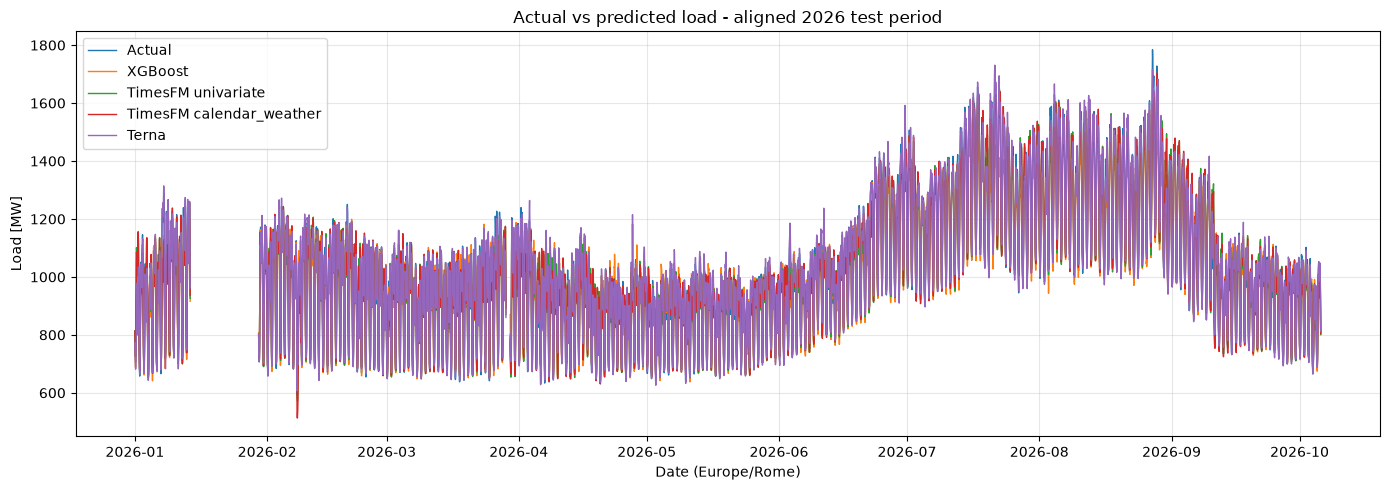

In [23]:
plot_labels_cov = {
    "actual": "Actual", "xgboost": "XGBoost",
    "timesfm_univariate": "TimesFM univariate",
    "timesfm_selected": f"TimesFM {selected_covariate_cov}", "terna": "Terna",
}
# Reindex only for plotting: NaNs break lines across skipped days, never fill them.
plot_index_cov = pd.date_range(
    final_comparison_cov.index.min(), final_comparison_cov.index.max(), freq="h"
)
plot_results_cov = final_comparison_cov.reindex(plot_index_cov)
plot_results_cov.index = plot_results_cov.index.tz_convert("Europe/Rome")

fig, ax = plt.subplots(figsize=(14, 5))
for column_cov, label_cov in plot_labels_cov.items():
    ax.plot(plot_results_cov.index, plot_results_cov[column_cov], label=label_cov, linewidth=1.0)
ax.set_title("Actual vs predicted load - aligned 2026 test period")
ax.set_xlabel("Date (Europe/Rome)")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The example week below is fixed to **August 6–12**, matching the existing XGBoost analysis. It is not selected by forecast error. Monthly, holiday, and summer-peak tables are descriptive only and do not alter the selected configuration. Signed bias is prediction minus actual: negative values indicate underprediction. Summer peaks use a fixed definition: June–August hours above the 90th percentile of pre-2026 load.

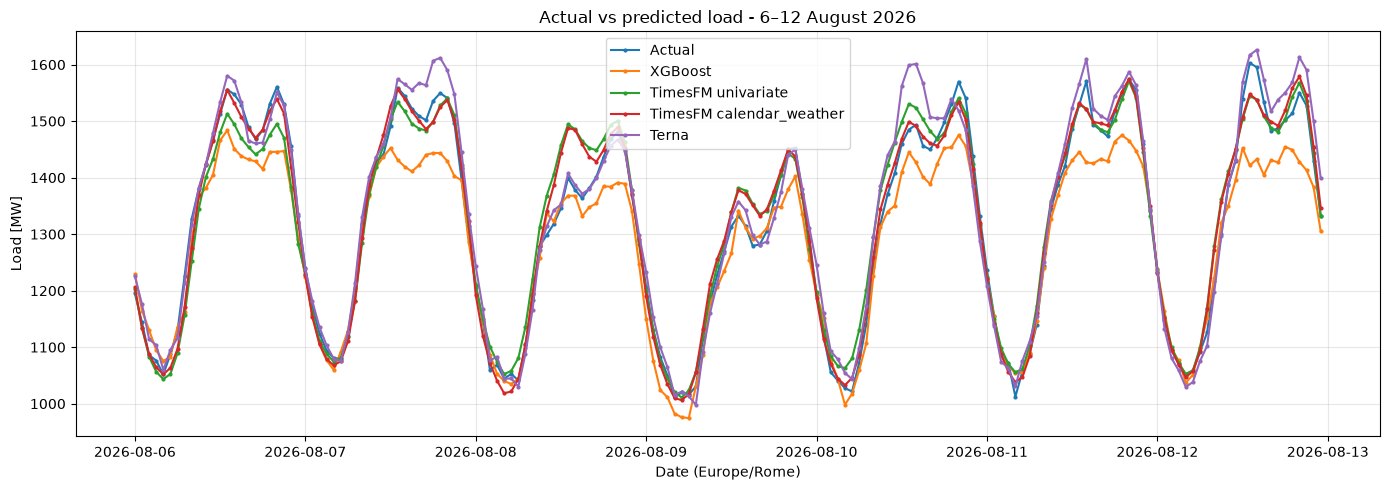

In [24]:
week_cov = plot_results_cov.loc["2026-08-06":"2026-08-12"]
fig, ax = plt.subplots(figsize=(14, 5))
for column_cov, label_cov in plot_labels_cov.items():
    ax.plot(week_cov.index, week_cov[column_cov], label=label_cov, marker="o", markersize=2)
ax.set_title("Actual vs predicted load - 6–12 August 2026")
ax.set_xlabel("Date (Europe/Rome)")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,month,model,observations,MAE [MW],MAPE [%],bias [MW]
0,1,xgboost,360,31.261,3.142,-17.436
1,1,timesfm_univariate,360,43.767,4.291,-8.270
2,1,timesfm_selected,360,45.896,4.495,-8.496
3,1,terna,360,18.151,1.901,-4.692
4,2,xgboost,672,25.424,2.666,3.164
5,2,timesfm_univariate,672,27.816,2.918,6.509
6,2,timesfm_selected,672,28.527,3.026,6.720
7,2,terna,672,13.150,1.348,-0.271
8,3,xgboost,720,24.764,2.662,-1.377
9,3,timesfm_univariate,720,31.441,3.286,-9.371


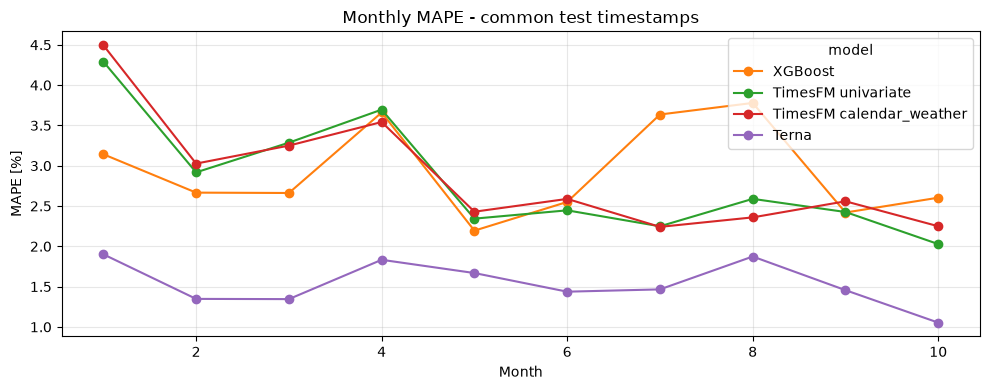

In [25]:
monthly_scores_cov = []
final_local_index_cov = final_comparison_cov.index.tz_convert("Europe/Rome")
for month_cov in sorted(set(final_local_index_cov.month)):
    rows_cov = final_comparison_cov.loc[final_local_index_cov.month == month_cov]
    for model_name_cov in final_model_names_cov:
        monthly_scores_cov.append({
            "month": month_cov, "model": model_name_cov, "observations": len(rows_cov),
            "MAE [MW]": mean_absolute_error(rows_cov["actual"], rows_cov[model_name_cov]),
            "MAPE [%]": 100 * mean_absolute_percentage_error(rows_cov["actual"], rows_cov[model_name_cov]),
            "bias [MW]": (rows_cov[model_name_cov] - rows_cov["actual"]).mean(),
        })
monthly_metrics_cov = pd.DataFrame(monthly_scores_cov)
display(monthly_metrics_cov.round(3))
monthly_mape_cov = monthly_metrics_cov.pivot(index="month", columns="model", values="MAPE [%]")
fig, ax = plt.subplots(figsize=(10, 4))
monthly_mape_cov = monthly_mape_cov[final_model_names_cov].rename(columns=plot_labels_cov)
monthly_mape_cov.plot(ax=ax, marker="o", color=["tab:orange", "tab:green", "tab:red", "tab:purple"])
ax.set_title("Monthly MAPE - common test timestamps")
ax.set_xlabel("Month")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
peak_threshold_cov = load_cov.loc[
    load_cov.index < test_start_cov.tz_convert("UTC"), "load"
].quantile(0.90)
holiday_mask_cov = covariate_df.loc[final_comparison_cov.index, "is_holiday"].eq(1)
summer_peak_mask_cov = (
    np.isin(final_local_index_cov.month, [6, 7, 8])
    & final_comparison_cov["actual"].ge(peak_threshold_cov)
)
subgroup_scores_cov = []
for group_cov, mask_cov in {
    "holiday": holiday_mask_cov,
    "non_holiday": ~holiday_mask_cov,
    "summer_peak": summer_peak_mask_cov,
}.items():
    rows_cov = final_comparison_cov.loc[mask_cov]
    if rows_cov.empty:
        continue
    for model_name_cov in final_model_names_cov:
        subgroup_scores_cov.append({
            "group": group_cov, "model": model_name_cov, "observations": len(rows_cov),
            "MAE [MW]": mean_absolute_error(rows_cov["actual"], rows_cov[model_name_cov]),
            "RMSE [MW]": np.sqrt(mean_squared_error(rows_cov["actual"], rows_cov[model_name_cov])),
            "MAPE [%]": 100 * mean_absolute_percentage_error(rows_cov["actual"], rows_cov[model_name_cov]),
            "bias [MW]": (rows_cov[model_name_cov] - rows_cov["actual"]).mean(),
        })
subgroup_metrics_cov = pd.DataFrame(subgroup_scores_cov)
print(f"Pre-2026 90th percentile load: {peak_threshold_cov:.2f} MW")
with pd.option_context("display.max_columns", None):
    display(subgroup_metrics_cov.round(3))

Pre-2026 90th percentile load: 1186.67 MW


,group,model,observations,MAE [MW],RMSE [MW],MAPE [%],bias [MW]
0,holiday,xgboost,216,34.858,44.945,3.786,-3.122
1,holiday,timesfm_univariate,216,46.077,65.573,5.185,34.600
2,holiday,timesfm_selected,216,46.910,64.955,5.305,38.213
3,holiday,terna,216,23.770,30.815,2.596,-13.856
4,non_holiday,xgboost,6048,31.936,47.200,2.926,-10.871
5,non_holiday,timesfm_univariate,6048,28.755,41.692,2.729,-2.260
6,non_holiday,timesfm_selected,6048,28.689,41.474,2.745,-0.817
7,non_holiday,terna,6048,16.126,22.779,1.530,2.624
8,summer_peak,xgboost,1156,60.740,80.809,4.167,-56.068
9,summer_peak,timesfm_univariate,1156,39.455,52.078,2.822,-5.850


In [27]:
# Save predictions and the validation-only decision for reproducible comparisons.
output_path_cov = Path("../data/processed")
validation_predictions_cov.to_parquet(output_path_cov / "timesfm_covariates_validation.parquet")
final_comparison_cov.to_parquet(output_path_cov / "timesfm_covariates_test.parquet")
validation_metrics_cov.to_csv(output_path_cov / "timesfm_covariates_validation_metrics.csv")
final_metrics_cov.to_csv(output_path_cov / "timesfm_covariates_test_metrics.csv")
validation_skipped_cov.to_csv(output_path_cov / "timesfm_covariates_validation_skipped.csv", index=False)
test_skipped_cov.to_csv(output_path_cov / "timesfm_covariates_test_skipped.csv", index=False)

monthly_metrics_cov.to_csv(output_path_cov / "timesfm_covariates_monthly_metrics.csv", index=False)
subgroup_metrics_cov.to_csv(output_path_cov / "timesfm_covariates_subgroup_metrics.csv", index=False)


In [28]:
validation_gain_cov = (
    validation_metrics_cov.loc["univariate", "MAE [MW]"]
    - validation_metrics_cov.loc[selected_covariate_cov, "MAE [MW]"]
)
test_gain_cov = (
    final_metrics_cov.loc["timesfm_univariate", "MAE [MW]"]
    - final_metrics_cov.loc["timesfm_selected", "MAE [MW]"]
)
display(Markdown(
    f"### Results interpretation\n\n"
    f"Validation used **{len(validation_predictions_cov):,} common hours**. "
    f"The selected overall configuration is **{best_configuration_cov}**, based on lowest validation MAE. "
    f"The best covariate challenger is **{selected_covariate_cov}**; "
    f"its MAE reduction versus the baseline is **{validation_gain_cov:.3f} MW** "
    "(negative means deterioration). The validation result does not support replacing univariate TimesFM.\n\n"
    f"The final comparison uses **{len(final_comparison_cov):,} common hours**. "
    f"The covariate challenger's MAE is just **{test_gain_cov:.3f} MW lower** than univariate TimesFM, "
    f"while its MAPE is **{final_metrics_cov.loc['timesfm_selected', 'MAPE [%]']:.3f}%**, "
    f"versus **{final_metrics_cov.loc['timesfm_univariate', 'MAPE [%]']:.3f}%** for the baseline. "
    "This is mixed, very small overall improvement, not evidence that the gap to Terna has materially closed. "
    f"Terna's MAPE is **{final_metrics_cov.loc['terna', 'MAPE [%]']:.3f}%**.\n\n"
    "**Holidays:** calendar-only validation MAE falls from 73.91 to 72.22 MW on 120 holiday hours, "
    "but overall validation MAE gets worse. The combined model's test holiday MAPE rises "
    "from 5.185% to 5.305%, so there is no consistent holiday benefit.\n\n"
    "**Summer:** the combined model improves August MAPE from 2.589% to 2.359%. "
    "On the predefined summer-peak subset, MAPE improves from 2.822% to 2.682%, "
    "and bias moves from -5.85 to +0.86 MW (XGBoost: -56.07 MW). "
    "This suggests a localized benefit, offset by deterioration in other months. "
    "Only the combined challenger was tested, so its test improvement cannot be attributed to weather alone.\n\n"
    "**Limits:** autumn-only validation provides no summer model-selection evidence. "
    "Holiday samples are small, and a 14-day context may contain no examples of an upcoming holiday. "
    "Unexpected anomalous days have no dedicated predictor in this fixed feature set. "
    "No uncertainty test establishes significance for the small differences. "
    "Weather issuance times and load publication latency cannot be audited from these parquet files, "
    "and foundation-model pretraining overlap is not independently verified. "
    "The interpretation describes this saved run; none of these test diagnostics changes the validation selection."
))


### Results interpretation

Validation used **2,184 common hours**. The selected overall configuration is **univariate**, based on lowest validation MAE. The best covariate challenger is **calendar_weather**; its MAE reduction versus the baseline is **-0.206 MW** (negative means deterioration). The validation result does not support replacing univariate TimesFM.

The final comparison uses **6,264 common hours**. The covariate challenger's MAE is just **0.036 MW lower** than univariate TimesFM, while its MAPE is **2.833%**, versus **2.814%** for the baseline. This is mixed, very small overall improvement, not evidence that the gap to Terna has materially closed. Terna's MAPE is **1.567%**.

**Holidays:** calendar-only validation MAE falls from 73.91 to 72.22 MW on 120 holiday hours, but overall validation MAE gets worse. The combined model's test holiday MAPE rises from 5.185% to 5.305%, so there is no consistent holiday benefit.

**Summer:** the combined model improves August MAPE from 2.589% to 2.359%. On the predefined summer-peak subset, MAPE improves from 2.822% to 2.682%, and bias moves from -5.85 to +0.86 MW (XGBoost: -56.07 MW). This suggests a localized benefit, offset by deterioration in other months. Only the combined challenger was tested, so its test improvement cannot be attributed to weather alone.

**Limits:** autumn-only validation provides no summer model-selection evidence. Holiday samples are small, and a 14-day context may contain no examples of an upcoming holiday. Unexpected anomalous days have no dedicated predictor in this fixed feature set. No uncertainty test establishes significance for the small differences. Weather issuance times and load publication latency cannot be audited from these parquet files, and foundation-model pretraining overlap is not independently verified. The interpretation describes this saved run; none of these test diagnostics changes the validation selection.